# We here try to estimate the parameters of the sterile male population

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.optimize as opt

In [2]:
file_rel = '/home/leo/Documents/These/Codes/SIT_models/Data/df_poly_release.csv' 
file_capt = '/home/leo/Documents/These/Codes/SIT_models/Data/df_poly_capture.csv'
df_rel = pd.read_csv(file_rel, sep=',')
df_capt = pd.read_csv(file_capt, sep=',')

## Lets keep the Onetahi capture and releases only

In [3]:
# Keep only the date, Motu and Nb_ind in the release df and onetahi motu
df_rel = df_rel[['Date', 'Motu', 'Nb_ind']]
df_rel = df_rel[df_rel['Motu'] == 'Onetahi']
df_rel = df_rel.drop(columns=['Motu'])

# Keep only the date, Motu and Nb_ind in the capture df and onetahi motu and then remove the motu column
df_capt = df_capt[['Date', 'Motu', 'Nb_ind']]
df_capt = df_capt[df_capt['Motu'] == 'Onetahi']
df_capt = df_capt.drop(columns=['Motu'])

# Group the capture by date and sum the number of individuals captured without deleting the data on the other columns
df_capt = df_capt.groupby('Date').sum().reset_index()

Since we look at the first release, we look for the capture happening on 2019 only

In [4]:
# Since we look at the first release, we look for the capture happening on 2019 only
df_capt = df_capt[df_capt['Date'].str.contains('2019')]
df_rel = df_rel[df_rel['Date'].str.contains('2019')]


# add one day to the release date to have the first day of capture after release
df_rel['Date'] = pd.to_datetime(df_rel['Date']) + pd.Timedelta(days=1)
df_capt['Date'] = pd.to_datetime(df_capt['Date'])

## Estimation plan

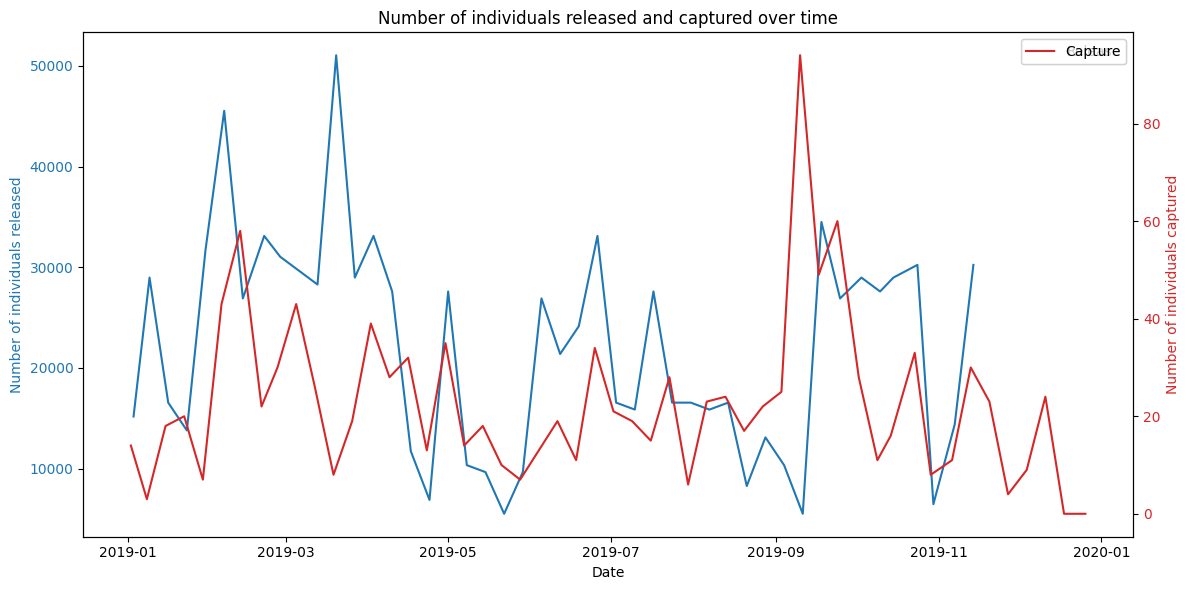

In [5]:
# Let's plot both capture and release with different scqle for the releqse qnd cqpture
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_rel, x='Date', y='Nb_ind', ax=ax1, label='Release', color='tab:blue')
ax1.set_ylabel('Number of individuals released', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=df_capt, x='Date', y='Nb_ind', ax=ax2, label='Capture', color='tab:red')
ax2.set_ylabel('Number of individuals captured', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Number of individuals released and captured over time')
fig.tight_layout()
plt.show()

In [6]:
#Lets replace the dates by the week number in the year
df_rel['Week'] = df_rel['Date'].dt.isocalendar().week
df_capt['Week'] = df_capt['Date'].dt.isocalendar().week

In [7]:
# Add missing weeks (1..52) to df_rel and set missing releases to 0
weeks = pd.DataFrame({'Week': range(1, 53)})

df_rel = weeks.merge(df_rel, on='Week', how='left')
df_rel['Nb_ind'] = df_rel['Nb_ind'].fillna(0)

# Optional: keep original column order
df_rel = df_rel[['Date', 'Nb_ind', 'Week']].sort_values('Week').reset_index(drop=True)

The goal is simple : given a sequence of release size, we want to estimate them with a Poisson model: each capture is a poisson realisation. We know the time and the size of each intervention, this can be computed in a log likelihood function.

In [8]:
def expected_captures(releases, week, delta):
    r_old = releases[releases["Week"] <= week - 2]
    r_prev = releases[releases["Week"] == week - 1]

    term_old = np.sum(
        r_old["Nb_ind"] * (
            np.exp(-delta * 7 * (week - r_old["Week"] - 1))
            - np.exp(-delta * 7 * (week - r_old["Week"]))
        )
    )

    term_prev = np.sum(
        r_prev["Nb_ind"] * (
            1 - np.exp(-delta * 7 * (week - r_prev["Week"] - 1))
        )
    )

    #releases = (np.sum(releases[releases['Week'] <= week - 2]['Nb_ind'] * ( np.exp(-delta * 7 *(week - releases['Week'] - 1)) - np.exp(-delta * 7 *  (week - releases['Week'])))) + releases[releases['Week'] == week-1]['Nb_ind'] * (1 -  np.exp(-delta * 7 * (week - releases['Week'] -1))))/delta
    return (term_old + term_prev) / delta

def loglikelihood(params, releases, captures, week):
    p = params[0]
    delta = params[1]
    ecaptures = expected_captures(releases, week, delta)
    ll = np.sum(captures * (np.log(p) + np.log(ecaptures)) - p * ecaptures)
    return -ll

In [9]:

def expected_captures(releases, week, delta):
    # week must be scalar (int/float), not a Series
    r_old = releases.loc[releases["Week"] <= week - 2]
    r_prev = releases.loc[releases["Week"] == week - 1]

    term_old = np.sum(
        r_old["Nb_ind"].to_numpy() * (
            np.exp(-delta * 7 * (week - r_old["Week"].to_numpy() - 1))
            - np.exp(-delta * 7 * (week - r_old["Week"].to_numpy()))
        )
    )

    term_prev = np.sum(
        r_prev["Nb_ind"].to_numpy() * (
            1 - np.exp(-delta * 7 * (week - r_prev["Week"].to_numpy() - 1))
        )
    )

    return (term_old + term_prev) / delta


def loglikelihood(params, releases, captures, weeks):
    p, delta = params

    # avoid log(0) and division by zero
    if p <= 0 or delta <= 0:
        return np.inf

    captures = np.asarray(captures, dtype=float)
    weeks = np.asarray(weeks, dtype=float)

    ecaptures = np.array([expected_captures(releases, w, delta) for w in weeks], dtype=float)
    ecaptures = np.clip(ecaptures, 1e-12, None)

    ll = np.sum(captures * (np.log(p) + np.log(ecaptures)) - p * ecaptures)
    return -ll

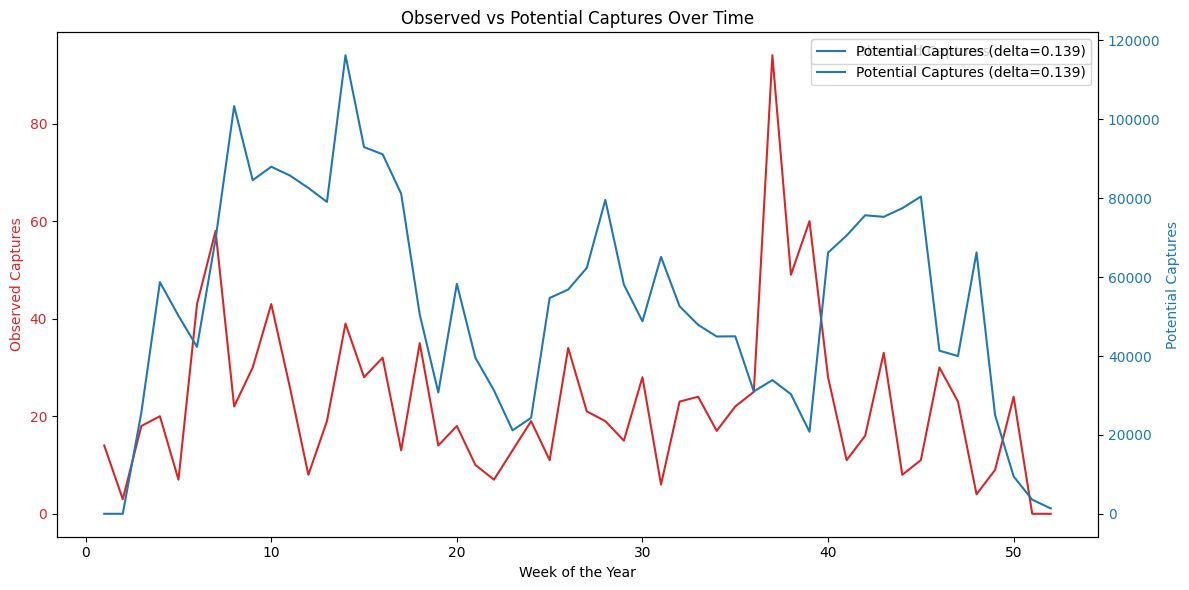

In [10]:
# Plot the expected captures for delta = 0.139
delta = 0.139
df_capt['Potential_Captures'] = df_capt['Week'].apply(lambda week: expected_captures(df_rel, week, delta))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Observed captures (left axis)
sns.lineplot(
    data=df_capt, x='Week', y='Nb_ind',
    ax=ax1, label='Observed Captures', color='tab:red'
)
ax1.set_xlabel('Week of the Year')
ax1.set_ylabel('Observed Captures', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Potential captures (right axis)
ax2 = ax1.twinx()
sns.lineplot(
    data=df_capt, x='Week', y='Potential_Captures',
    ax=ax2, label='Potential Captures (delta=0.139)', color='tab:blue'
)
ax2.set_ylabel('Potential Captures', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Observed vs Potential Captures Over Time')
fig.tight_layout()
plt.show()

We want to maximize the log likelihood. The two unknown parameters are the death rate delta and capture rate p.

In [11]:
val = opt.minimize(
    loglikelihood,
    x0=[0.1, 0.139],
    args=(df_rel, df_capt["Nb_ind"].to_numpy(), df_capt["Week"].to_numpy()),
    bounds=[(1e-12, 1), (1e-12, 1)],
    method="L-BFGS-B"
)

In [12]:
val

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -1726.5119433342536
        x: [ 3.599e-03  3.193e-01]
      nit: 19
      jac: [ 1.281e+04 -1.444e+02]
     nfev: 114
     njev: 38
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

# Test data

\begin{table}[h!]
    \centering
    \begin{tabular}{| c | c | c | }
        \hline
        Size of releases and Parameters $(\alpha, \delta_M)$ & Estimations  \\ \hline
        Size $20000$ $(0.01, 0)$ & $\tau_E $ \\
        Size $20000$ $(0.01, 1)$ & $\tau_E $ \\
        Size $20000$ $(0.01, 0.1)$ & $\beta$ \\
        \hline
        Size $20000$ $(0.001, 0)$ & $\tau_E $ \\
        Size $20000$ $(0.001, 1)$ & $\tau_E $ \\
        Size $20000$ $(0.001, 0.1)$ & $\beta$ \\
        \hline
        Size $20000$ $(0.0001, 0)$ & $\tau_E $ \\
        Size $20000$ $(0.0001, 1)$ & $\tau_E $ \\
        Size $20000$ $(0.0001, 0.1)$ & $\beta$ \\
        \hline
    \end{tabular}
    \caption{Estimation result for simulations}
    \label{tab:Poly_rates}
\end{table}

In [13]:
#first dataset, we run a population estimation with release size = 20000, death rate = 0, and capture rate = 0.1
# first dataset: release size = 20000, death rate = 0, capture rate = 0.1
# expected_captures expects a scalar week, and delta must be > 0 in current formula
weeks_sim = np.arange(1, 53)  # 52 weeks to match df_capt / df_rel
delta_sim = 0.5
delta_eff = 1e-12 if delta_sim == 0 else delta_sim  # avoid division by zero

#rel_sim = pd.DataFrame({'Week': weeks_sim, 'Nb_ind': [20000 for w in weeks_sim]})
# Pop_sim = np.array([expected_captures(rel_sim, week=w, delta=delta_eff) for w in weeks_sim])

Pop_sim = np.array([expected_captures(df_rel, week=w, delta=delta_eff) for w in weeks_sim])

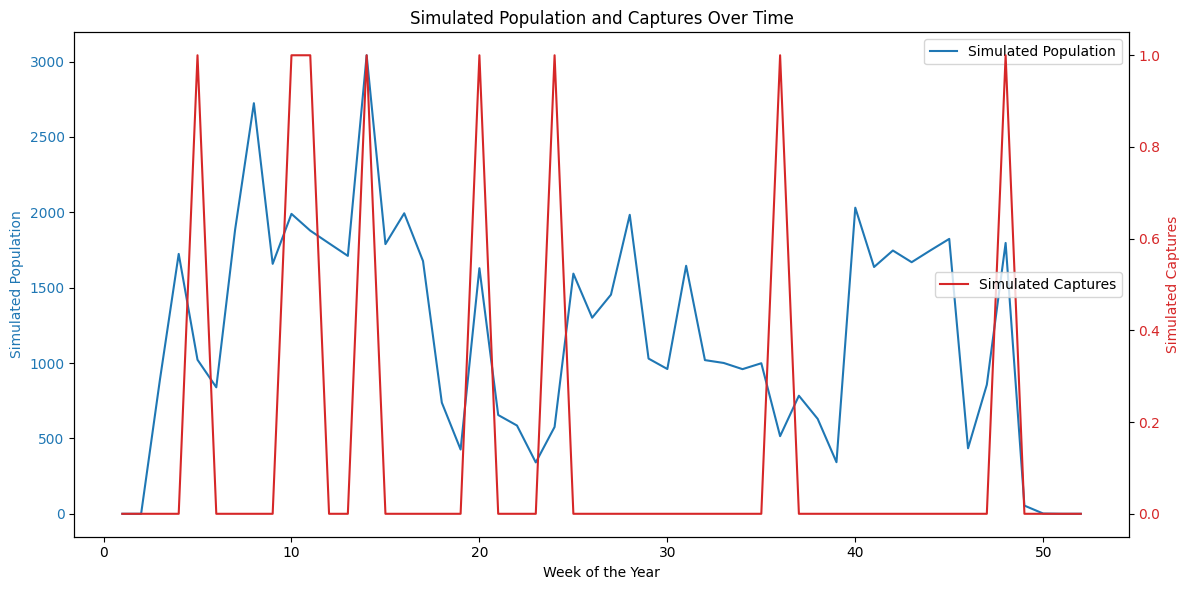

In [14]:
# now get the capture on each week with the capture rate of 0.01
capt_rate = 0.0001
capt_sim_expectation = capt_rate * Pop_sim
capt_sim = np.random.poisson(capt_sim_expectation)

# Plot the simulated population and captures
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(x=weeks_sim, y=Pop_sim, ax=ax1, label='Simulated Population', color='tab:blue')
ax1.set_xlabel('Week of the Year')
ax1.set_ylabel('Simulated Population', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(x=weeks_sim, y=capt_sim, ax=ax2, label='Simulated Captures', color='tab:red')
ax2.set_ylabel('Simulated Captures', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Simulated Population and Captures Over Time')
fig.tight_layout()
plt.show()

In [15]:
# now run the estimation on the simulated data
val_sim = opt.minimize(
    loglikelihood,
    x0=[0.1, 0.139],
    args=(df_rel, capt_sim, weeks_sim),
    bounds=[(1e-12, 1), (1e-12, 1)],
    method="L-BFGS-B"
)
val_sim

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 22.007201065686925
        x: [ 2.900e-04  5.909e-01]
      nit: 12
      jac: [-1.433e-02 -6.239e-02]
     nfev: 72
     njev: 24
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [20]:
# make a function that takes as input the release sizes, weeks and death rate and capture rate It should return the optimize solution of the optimization problem
def estimate_parameters(releases, deltasim, capt_rate, weeks, tol = 1e-12):
    delta_eff = 1e-12 if deltasim == 0 else deltasim
    Pop_sim = np.array([expected_captures(releases, week=w, delta=delta_eff) for w in weeks])
    
    # now get the capture on each week with the capture rate of 0.01
    capt_sim = np.random.poisson(capt_rate * Pop_sim)

    val = opt.minimize(
        loglikelihood,
        x0=[0.001, 0.139],
        args=(releases, capt_sim, weeks),
        bounds=[(1e-12, 0.01), (1e-12, 0.5)],
        method="L-BFGS-B",
        tol = tol
    )
    return val

In [21]:
estimate_parameters(df_rel, deltasim=0.1, capt_rate=0.0001, weeks=weeks_sim)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -760.2557585451257
        x: [ 9.807e-05  9.612e-02]
      nit: 21
      jac: [ 8.644e+02 -1.186e+00]
     nfev: 138
     njev: 46
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [24]:
# Multiple simu 
n_simulations = 50
current_deltasim = 0.1
current_capt_rate = 0.0001

results = []
for i in range(n_simulations):
    val_sim = estimate_parameters(df_rel, deltasim=current_deltasim, capt_rate=current_capt_rate, weeks=weeks_sim)
    results.append(val_sim.x)
    print(i)
results_df = pd.DataFrame(results, columns=['Capture Rate', 'Death Rate'])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


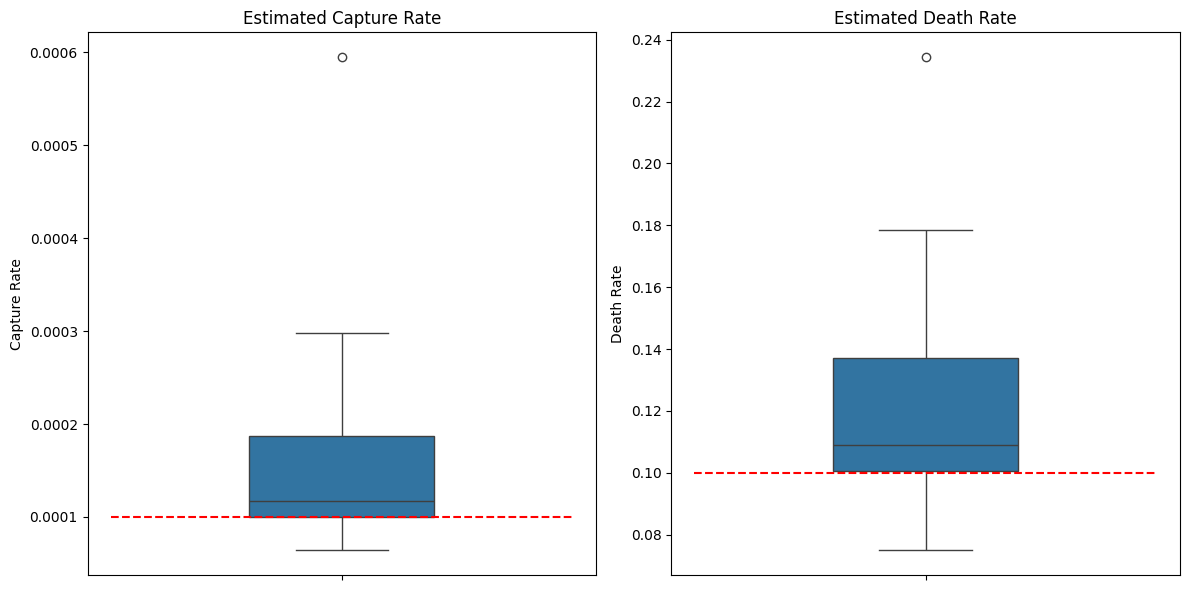

In [25]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(results_df['Capture Rate'], ax=ax[0])
sns.boxplot(results_df['Death Rate'], ax=ax[1])
ax[0].hlines(current_capt_rate, -1, 1, colors='red', linestyles='dashed')
ax[1].hlines(current_deltasim, -1, 1, colors='red', linestyles='dashed')
ax[0].set_title('Estimated Capture Rate')
ax[1].set_title('Estimated Death Rate')
plt.tight_layout()
plt.show()